In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from lifelines import KaplanMeierFitter
from scipy.stats import norm, logistic, gumbel_r
from numpy import array

# Evaluation of all models

1. Deciduous
   1. Lifelines (ensemble)
   2. XGBoost
   3. Catboost
2. Permanent
   1. Lifelines (ensemble)
   2. XGBoost
   3. Catboost
3. Linear AFT on full teeth data

Methods:
- Time-Dependent Brier Score
- Time-Dependent AUC
- Calibration

## Deciduous

### Load data

In [3]:
deciduous_teeth_all = pd.read_csv("../data/deciduous_teeth.csv", sep=";")

### Preprocess data

In [4]:
def preprocess_data_lifelines(df):
    df = df.copy()
    df.loc[((df["LOWER"].isna()), "LOWER")] = 0
    df.loc[((df["UPPER"].isna()), "UPPER")] = np.inf

    return df

In [5]:
deciduous_teeth_all = preprocess_data_lifelines(deciduous_teeth_all)

### Inladen predictions nested CV

In [6]:
# results nested cv
ll_preds = pd.read_csv(f"preds\\ll_tooth_preds_dec.csv", sep=";")
xgb_preds = pd.read_csv(f"preds\\xgb_tooth_preds_dec.csv", sep=";")
cb_preds = pd.read_csv(f"preds\\cb_tooth_preds_dec.csv", sep=";")

In [7]:
# filter ll preds to have same order as deciduous_teeth
ll_preds["TOOTH_NUMBER"] = pd.Categorical(
    ll_preds["TOOTH_NUMBER"], deciduous_teeth_all["TOOTH_NUMBER"].unique()
)
ll_preds = ll_preds.sort_values(
    ["DOG", "TOOTH_NUMBER", "DEVELOPM_STAGE"], ignore_index=True
)

In [8]:
# add dog, tooth_nr, developm_stage to xgb and cb
xgb_preds["DOG"] = deciduous_teeth_all["DOG"]
xgb_preds["TOOTH_NUMBER"] = deciduous_teeth_all["TOOTH_NUMBER"]
xgb_preds["DEVELOPM_STAGE"] = deciduous_teeth_all["DEVELOPM_STAGE"]
cb_preds["DOG"] = deciduous_teeth_all["DOG"]
cb_preds["TOOTH_NUMBER"] = deciduous_teeth_all["TOOTH_NUMBER"]
cb_preds["DEVELOPM_STAGE"] = deciduous_teeth_all["DEVELOPM_STAGE"]

In [9]:
def get_distribution(dist_name):
    if dist_name == "Normal" or dist_name == "normal":
        return norm
    elif dist_name == "Logistic" or dist_name == "logistic":
        return logistic
    elif dist_name == "Extreme" or dist_name == "extreme":
        return gumbel_r
    else:
        raise ValueError("Invalid distribution name")


def compute_survival_probability(preds, timepoint, dist_name="Normal", scale=1.0):
    dist = get_distribution(dist_name)
    log_time = np.log(timepoint)
    survival_probs = 1 - dist.cdf((log_time - preds) / scale)
    return survival_probs

### Brier Score

In [ ]:
def brier_score_lifelines(preds, timepoint, delta, df):
    # n_t = #individuen die event niet hebben ervaren of censored zijn until tijstip t = # still at risk
    n_t = len(
        df[
            ((df["CENS"].isin([0, 2])) & (df["UPPER"] > timepoint))
            | ((df["CENS"].isin([3, 4, 5])) & (df["LOWER"] > timepoint))
        ]
    )

    # subjects die event in interval [t, t+delta] hebben
    subjs_event = df[
        ((df["LOWER"] >= timepoint) & (df["LOWER"] <= timepoint + delta))
        & ((df["UPPER"] >= timepoint) & (df["UPPER"] <= timepoint + delta))
    ]
    subjs_event_idx = subjs_event.index

    # subjects die geen event hebben tot t+delta
    subjs_no_event_idx = df[df["LOWER"] > timepoint + delta].index

    # future lifetime --> 2* : voor beide subjs groepen
    subjs_event_surv_t = (
        preds[preds["time"] == timepoint]
        .reset_index(drop=True)
        .iloc[subjs_event_idx]["pred_survival"]
        .values
    )
    subjs_event_surv_t_delta = (
        preds[preds["time"] == timepoint + delta]
        .reset_index(drop=True)
        .iloc[subjs_event_idx]["pred_survival"]
        .values
    )

    subjs_event_surv_t = array(subjs_event_surv_t)
    subjs_event_surv_t = np.where(subjs_event_surv_t == 0, 1e-12, subjs_event_surv_t)
    subjs_event_surv_t_delta = array(subjs_event_surv_t_delta)

    subjs_no_event_surv_t = (
        preds[preds["time"] == timepoint]
        .reset_index(drop=True)
        .iloc[subjs_no_event_idx]["pred_survival"]
        .values
    )
    subjs_no_event_surv_t_delta = (
        preds[preds["time"] == timepoint + delta]
        .reset_index(drop=True)
        .iloc[subjs_no_event_idx]["pred_survival"]
        .values
    )

    subjs_no_event_surv_t = array(subjs_no_event_surv_t)
    subjs_no_event_surv_t = np.where(
        subjs_no_event_surv_t == 0, 1e-12, subjs_no_event_surv_t
    )
    subjs_no_event_surv_t_delta = array(subjs_no_event_surv_t_delta)
    # fl
    subjs_event_fl = (
        subjs_event_surv_t - subjs_event_surv_t_delta
    ) / subjs_event_surv_t
    # subjs_event_fl.reset_index(drop=True, inplace=True, allow_duplicates=True)

    subjs_no_event_fl = (
        subjs_no_event_surv_t - subjs_no_event_surv_t_delta
    ) / subjs_no_event_surv_t

    # gewichten: obv Kaplan-Meier waar censoring als event wordt gezien
    censoring_times = []
    censoring_events = []

    for _, row in df.iterrows():
        # right censoring as event
        if row["UPPER"] == np.inf:
            censoring_times.append(row["LOWER"])
            censoring_events.append(True)
        else:
            censoring_times.append(row["UPPER"])
            censoring_events.append(False)

    kmf = KaplanMeierFitter()
    kmf.fit(censoring_times, censoring_events)

    w_i = 1 / np.clip(
        kmf.predict(subjs_event["UPPER"]), 1e-12, kmf.predict(subjs_event["UPPER"])
    )
    w_i = (
        w_i.reset_index(drop=True, allow_duplicates=True)
        if type(w_i) == pd.core.series.Series
        else w_i
    )

    w_i_2 = 1 / np.clip(
        kmf.predict(timepoint + delta), 1e-12, kmf.predict(timepoint + delta)
    )

    # Brier score
    left_side = (((1 - subjs_event_fl) ** 2) * w_i).sum()
    right_side = (((0 - subjs_no_event_fl) ** 2) * w_i_2).sum()

    bs = 1 / (n_t) * (left_side + right_side)

    if bs <= 1:
        return bs
    else:
        return 1

In [ ]:
def brier_score_catboost(preds, timepoint, delta, df):
    # n_t = #individuen die event niet hebben ervaren of censored zijn until tijstip t = # still at risk
    n_t = len(
        df[
            ((df["CENS"].isin([0, 2])) & (df["UPPER"] > timepoint))
            | ((df["CENS"].isin([3, 4, 5])) & (df["LOWER"] > timepoint))
        ]
    )

    # subjects die event in interval [t, t+delta] hebben
    subjs_event = df[
        ((df["LOWER"] >= timepoint) & (df["LOWER"] <= timepoint + delta))
        & ((df["UPPER"] >= timepoint) & (df["UPPER"] <= timepoint + delta))
    ]
    subjs_event_idx = subjs_event.index

    # subjects die geen event hebben tot t+delta
    subjs_no_event_idx = df[df["LOWER"] > timepoint + delta].index

    subjs_event_preds = preds.iloc[subjs_event_idx]
    subjs_event_preds.reset_index(inplace=True, drop=True)
    # future lifetime --> 2* : voor beide subjs groepen
    subjs_event_surv_t = []
    for i in range(len(subjs_event_preds)):
        subjs_event_surv_t.extend(
            compute_survival_probability(
                [subjs_event_preds.loc[i]["pred"]],
                timepoint,
                subjs_event_preds.loc[i]["dist"],
                subjs_event_preds.loc[i]["scale"],
            )
        )
    subjs_event_surv_t = array(subjs_event_surv_t)
    subjs_event_surv_t = np.where(subjs_event_surv_t == 0, 1e-12, subjs_event_surv_t)

    subjs_event_surv_t_delta = []
    for i in range(len(subjs_event_preds)):
        subjs_event_surv_t_delta.extend(
            compute_survival_probability(
                [subjs_event_preds.loc[i]["pred"]],
                timepoint + delta,
                subjs_event_preds.loc[i]["dist"],
                subjs_event_preds.loc[i]["scale"],
            )
        )
    subjs_event_surv_t_delta = array(subjs_event_surv_t_delta)

    subjs_no_event_preds = preds.iloc[subjs_no_event_idx]
    subjs_no_event_preds.reset_index(inplace=True, drop=True)
    subjs_no_event_surv_t = []
    for i in range(len(subjs_no_event_preds)):
        subjs_no_event_surv_t.extend(
            compute_survival_probability(
                [subjs_no_event_preds.loc[i]["pred"]],
                timepoint,
                subjs_no_event_preds.loc[i]["dist"],
                subjs_no_event_preds.loc[i]["scale"],
            )
        )
    subjs_no_event_surv_t = array(subjs_no_event_surv_t)
    subjs_no_event_surv_t = np.where(
        subjs_no_event_surv_t == 0, 1e-12, subjs_no_event_surv_t
    )

    subjs_no_event_surv_t_delta = []
    for i in range(len(subjs_no_event_preds)):
        subjs_no_event_surv_t_delta.extend(
            compute_survival_probability(
                [subjs_no_event_preds.loc[i]["pred"]],
                timepoint + delta,
                subjs_no_event_preds.loc[i]["dist"],
                subjs_no_event_preds.loc[i]["scale"],
            )
        )
    subjs_no_event_surv_t_delta = array(subjs_no_event_surv_t_delta)

    subjs_event_fl = (
        subjs_event_surv_t - subjs_event_surv_t_delta
    ) / subjs_event_surv_t
    subjs_no_event_fl = (
        subjs_no_event_surv_t - subjs_no_event_surv_t_delta
    ) / subjs_no_event_surv_t

    # gewichten: obv Kaplan-Meier waar  censoring als event wordt gezien
    censoring_times = []
    censoring_events = []

    for _, row in df.iterrows():
        # right censoring as event
        if row["UPPER"] == np.inf:
            censoring_times.append(row["LOWER"])
            censoring_events.append(True)
        else:
            censoring_times.append(row["UPPER"])
            censoring_events.append(False)

    kmf = KaplanMeierFitter()
    kmf.fit(censoring_times, censoring_events)

    w_i = 1 / np.clip(
        kmf.predict(subjs_event["UPPER"]), 1e-12, kmf.predict(subjs_event["UPPER"])
    )
    w_i.reset_index(drop=True, inplace=True, allow_duplicates=True)
    w_i = w_i / w_i.mean()

    w_i_2 = 1 / np.clip(
        kmf.predict(timepoint + delta), 1e-12, kmf.predict(timepoint + delta)
    )

    # Brier score
    left_side = (((1 - subjs_event_fl) ** 2) * w_i).sum()
    right_side = (((0 - subjs_no_event_fl) ** 2) * w_i_2).sum()

    bs = 1 / (n_t) * (left_side + right_side)

    if bs <= 1:
        return bs
    else:
        return 1

#### Time-Dependent Brier Score

In [11]:
def time_dependent_bs_lifelines(preds, timepoints, delta, df):
    bs_vals = []

    for timepoint in timepoints:
        bs_vals.append(brier_score_lifelines(preds, timepoint, delta, df))

    return bs_vals

In [12]:
def time_dependent_bs_catboost(preds, timepoints, delta, df):
    # timepoints = np.arange(start_time, end_time, delta)

    bs_vals = []

    for timepoint in timepoints:
        bs_t = brier_score_catboost(preds, timepoint, delta, df)
        print(f"Brier Score at time {timepoint}: {bs_t}")
        bs_vals.append(bs_t)

    return bs_vals

#### Compare Models

##### Static delta t

In [13]:
print(brier_score_lifelines(ll_preds, 11, 46, deciduous_teeth_all))
print(brier_score_catboost(xgb_preds, 11, 46, deciduous_teeth_all))
print(brier_score_catboost(cb_preds, 11, 46, deciduous_teeth_all))

0.01480875290980186
0.023335135075060357
0.016544695876727224


In [14]:
(
    deciduous_teeth_all[deciduous_teeth_all["UPPER"] != np.inf]["UPPER"]
    - deciduous_teeth_all[deciduous_teeth_all["LOWER"] != 0]["LOWER"]
).mean()

np.float64(7.032511894595584)

In [15]:
deciduous_teeth_all[
    (deciduous_teeth_all["UPPER"] != np.inf) & (deciduous_teeth_all["LOWER"] != 0)
][["LOWER", "UPPER"]].describe()

,LOWER,UPPER
count,16394.000000,16394.000000
mean,31.892766,38.925278
std,10.351227,12.175162
min,11.000000,11.000000
25%,24.000000,29.000000
50%,30.000000,38.000000
75%,37.000000,46.000000
max,100.000000,129.000000


In [16]:
deciduous_teeth_all[deciduous_teeth_all["UPPER"] != np.inf]["UPPER"].max()

np.float64(129.0)

In [ ]:
def get_counts(df, timepoint, delta):
    n_t = len(
        df[
            ((df["CENS"].isin([0, 2])) & (df["UPPER"] > timepoint))
            | ((df["CENS"].isin([3, 4, 5])) & (df["LOWER"] > timepoint))
        ]
    )

    # subjects die event in interval [t, t+delta] hebben
    subjs_event = len(
        df[
            ((df["LOWER"] >= timepoint) & (df["LOWER"] <= timepoint + delta))
            & ((df["UPPER"] >= timepoint) & (df["UPPER"] <= timepoint + delta))
        ]
    )

    # subjects die geen event hebben tot t+delta
    subjs_no_event = len(df[df["LOWER"] > timepoint + delta])

    return n_t, subjs_event, subjs_no_event

In [18]:
deciduous_teeth[(deciduous_teeth["LOWER"] != 0) & (deciduous_teeth["UPPER"] != np.inf)][
    ["LOWER", "UPPER"]
].quantile(0.95)

LOWER    50.0
UPPER    58.0
Name: 0.95, dtype: float64

In [19]:
START_D = 11
END_D = 60
DELTA_D = 7

TIMEPOINTS = np.arange(START_D, END_D, DELTA_D)

for timepoint in TIMEPOINTS:
    print(get_counts(deciduous_teeth_all, timepoint, DELTA_D))

(52928, 157, 23068)
(52145, 1489, 16781)
(43223, 1676, 10187)
(31799, 737, 6189)
(23117, 940, 3431)
(15173, 428, 1694)
(10734, 171, 736)


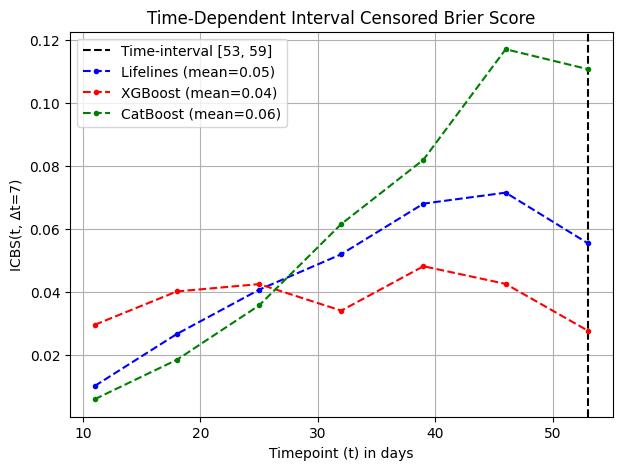

In [20]:
START_D = 11
END_D = 60
DELTA_D = 7

TIMEPOINTS = np.arange(START_D, END_D, DELTA_D)

# bs_lifelines = time_dependent_bs_lifelines(
#     ll_preds, TIMEPOINTS, DELTA_D, deciduous_teeth_all
# )
# print(bs_lifelines)
bs_lifelines = [
    np.float64(0.010090708522958302),
    np.float64(0.026627826192220982),
    np.float64(0.04068452527075413),
    np.float64(0.05197179138158601),
    np.float64(0.06805136650120147),
    np.float64(0.07154485273574515),
    np.float64(0.05544803563922888),
]

# bs_xgboost = time_dependent_bs_catboost(
#     xgb_preds, TIMEPOINTS, DELTA_D, deciduous_teeth_all
# )
# print(bs_xgboost)
bs_xgboost = [
    np.float64(0.029534294611373205),
    np.float64(0.04014773994686864),
    np.float64(0.042475030379945856),
    np.float64(0.0340433416227858),
    np.float64(0.048152372727475024),
    np.float64(0.04253696659891115),
    np.float64(0.027673068630856768),
]

# bs_catboost = time_dependent_bs_catboost(
#     cb_preds, TIMEPOINTS, DELTA_D, deciduous_teeth_all
# )
# print(bs_catboost)
bs_catboost = [
    np.float64(0.005889477806999384),
    np.float64(0.018424329538857045),
    np.float64(0.035692011014373554),
    np.float64(0.0615665697187639),
    np.float64(0.08202501611860159),
    np.float64(0.1171293106494248),
    np.float64(0.11079522193385906),
]


plt.figure(figsize=(7, 5))
# plt.axhline(y=0.25, color="gray", linestyle="--", label="Random predictor (ICBS=0.25)")
plt.axvline(x=53, color="black", linestyle="--", label="Time-interval [53, 59]")
plt.plot(
    TIMEPOINTS,
    bs_lifelines,
    marker=".",
    linestyle="--",
    color="blue",
    label=f"Lifelines (mean={np.mean(bs_lifelines):.2f})",
)
plt.plot(
    TIMEPOINTS,
    bs_xgboost,
    marker=".",
    linestyle="--",
    color="red",
    label=f"XGBoost (mean={np.mean(bs_xgboost):.2f})",
)
plt.plot(
    TIMEPOINTS,
    bs_catboost,
    marker=".",
    linestyle="--",
    color="green",
    label=f"CatBoost (mean={np.mean(bs_catboost):.2f})",
)
plt.xlabel("Timepoint (t) in days")
plt.ylabel(f"ICBS(t, Δt={DELTA_D})")
plt.title("Time-Dependent Interval Censored Brier Score")
plt.legend()
plt.grid()
plt.show()

### AUC

#### Sensitivity

In [10]:
def sensitivity_lifelines(c: float, timepoint: int, delta: int, preds, df, kmf):
    # subjects die event in interval [t, t+delta] hebben
    subjs_event = df[
        ((df["LOWER"] >= timepoint) & (df["LOWER"] <= timepoint + delta))
        & ((df["UPPER"] >= timepoint) & (df["UPPER"] <= timepoint + delta))
    ]
    subjs_event_idx = subjs_event.index

    # future lifetime
    subjs_event_surv_t = (
        preds[preds["time"] == timepoint]
        .reset_index(drop=True)
        .iloc[subjs_event_idx]["pred_survival"]
        .values
    )
    subjs_event_surv_t_delta = (
        preds[preds["time"] == timepoint + delta]
        .reset_index(drop=True)
        .iloc[subjs_event_idx]["pred_survival"]
        .values
    )
    subjs_event_surv_t = array(subjs_event_surv_t)
    subjs_event_surv_t = np.where(subjs_event_surv_t == 0, 1e-12, subjs_event_surv_t)
    subjs_event_surv_t_delta = array(subjs_event_surv_t_delta)

    subjs_event_fl = (
        subjs_event_surv_t - subjs_event_surv_t_delta
    ) / subjs_event_surv_t
    # subjs_event_fl.reset_index(drop=True, inplace=True, allow_duplicates=True)

    # check als fl >= c
    I_fl = subjs_event_fl >= c
    I_fl = I_fl.astype(int)

    # gewichten: obv Kaplan-Meier waar censoring als event wordt gezien
    # censoring_times = []
    # censoring_events = []

    # for _, row in df.iterrows():
    #     # right censoring as event
    #     if row["UPPER"] == np.inf:
    #         censoring_times.append(row["LOWER"])
    #         censoring_events.append(True)
    #     else:
    #         censoring_times.append(row["UPPER"])
    #         censoring_events.append(False)

    # kmf = KaplanMeierFitter()
    # kmf.fit(censoring_times, censoring_events)

    w_i = 1 / np.clip(
        kmf.predict(subjs_event["UPPER"]), 1e-12, kmf.predict(subjs_event["UPPER"])
    )
    w_i = (
        w_i.reset_index(drop=True, allow_duplicates=True)
        if type(w_i) == pd.core.series.Series
        else w_i
    )

    # calc sen
    teller = (I_fl * w_i).sum()
    sen = teller / w_i.sum()

    return sen

In [11]:
def sensitivity_catboost(c: float, timepoint: int, delta: int, preds, df, kmf):
    # subjects die event in interval [t, t+delta] hebben
    subjs_event = df[
        ((df["LOWER"] >= timepoint) & (df["LOWER"] <= timepoint + delta))
        & ((df["UPPER"] >= timepoint) & (df["UPPER"] <= timepoint + delta))
    ]
    subjs_event_idx = subjs_event.index

    subjs_event_preds = preds.iloc[subjs_event_idx]
    subjs_event_preds.reset_index(inplace=True, drop=True)
    # future lifetime --> 2* : voor beide subjs groepen
    subjs_event_surv_t = []
    for i in range(len(subjs_event_preds)):
        subjs_event_surv_t.extend(
            compute_survival_probability(
                [subjs_event_preds.loc[i]["pred"]],
                timepoint,
                subjs_event_preds.loc[i]["dist"],
                subjs_event_preds.loc[i]["scale"],
            )
        )
    subjs_event_surv_t = array(subjs_event_surv_t)
    subjs_event_surv_t = np.where(subjs_event_surv_t == 0, 1e-12, subjs_event_surv_t)

    subjs_event_surv_t_delta = []
    for i in range(len(subjs_event_preds)):
        subjs_event_surv_t_delta.extend(
            compute_survival_probability(
                [subjs_event_preds.loc[i]["pred"]],
                timepoint + delta,
                subjs_event_preds.loc[i]["dist"],
                subjs_event_preds.loc[i]["scale"],
            )
        )
    subjs_event_surv_t_delta = array(subjs_event_surv_t_delta)
    subjs_event_fl = (
        subjs_event_surv_t - subjs_event_surv_t_delta
    ) / subjs_event_surv_t

    # check als fl >= c
    I_fl = subjs_event_fl >= c
    I_fl = I_fl.astype(int)

    # gewichten: obv Kaplan-Meier waar censoring als event wordt gezien
    # censoring_times = []
    # censoring_events = []

    # for _, row in df.iterrows():
    #     # right censoring as event
    #     if row["UPPER"] == np.inf:
    #         censoring_times.append(row["LOWER"])
    #         censoring_events.append(True)
    #     else:
    #         censoring_times.append(row["UPPER"])
    #         censoring_events.append(False)

    # kmf = KaplanMeierFitter()
    # kmf.fit(censoring_times, censoring_events)

    w_i = 1 / np.clip(
        kmf.predict(subjs_event["UPPER"]), 1e-12, kmf.predict(subjs_event["UPPER"])
    )

    # calc sen
    teller = (I_fl * w_i).sum()
    sen = teller / w_i.sum()

    return sen

#### Specificity

In [12]:
def specificity_lifelines(c: float, timepoint: int, delta: int, preds, df, kmf):
    # subjects die geen event hebben tot t+delta
    subjs_no_event = df[df["LOWER"] > timepoint + delta]
    subjs_no_event_idx = subjs_no_event.index

    # future lifetime
    subjs_no_event_surv_t = (
        preds[preds["time"] == timepoint]
        .reset_index(drop=True)
        .iloc[subjs_no_event_idx]["pred_survival"]
        .values
    )
    subjs_no_event_surv_t_delta = (
        preds[preds["time"] == timepoint + delta]
        .reset_index(drop=True)
        .iloc[subjs_no_event_idx]["pred_survival"]
        .values
    )
    subjs_no_event_surv_t = array(subjs_no_event_surv_t)
    subjs_no_event_surv_t = np.where(
        subjs_no_event_surv_t == 0, 1e-12, subjs_no_event_surv_t
    )
    subjs_no_event_surv_t_delta = array(subjs_no_event_surv_t_delta)

    subjs_no_event_fl = (
        subjs_no_event_surv_t - subjs_no_event_surv_t_delta
    ) / subjs_no_event_surv_t

    # check als fl < c
    I_fl = subjs_no_event_fl < c
    I_fl = I_fl.astype(int)

    # gewichten: obv Kaplan-Meier waar censoring als event wordt gezien
    # censoring_times = []
    # censoring_events = []

    # for _, row in df.iterrows():
    #     # right censoring as event
    #     if row["UPPER"] == np.inf:
    #         censoring_times.append(row["LOWER"])
    #         censoring_events.append(True)
    #     else:
    #         censoring_times.append(row["UPPER"])
    #         censoring_events.append(False)

    # kmf = KaplanMeierFitter()
    # kmf.fit(censoring_times, censoring_events)

    w_i_2 = 1 / np.clip(
        kmf.predict(timepoint + delta), 1e-12, kmf.predict(timepoint + delta)
    )

    # calc spe
    teller = (I_fl * w_i_2).sum()
    spe = teller / (w_i_2 * len(subjs_no_event))

    return spe

In [13]:
def specificity_catboost(c: float, timepoint: int, delta: int, preds, df, kmf):
    # subjects die geen event hebben tot t+delta
    subjs_no_event = df[df["LOWER"] > timepoint + delta]
    subjs_no_event_idx = subjs_no_event.index

    # future lifetime
    subjs_no_event_preds = preds.iloc[subjs_no_event_idx]
    subjs_no_event_preds.reset_index(inplace=True, drop=True)
    subjs_no_event_surv_t = []
    for i in range(len(subjs_no_event_preds)):
        subjs_no_event_surv_t.extend(
            compute_survival_probability(
                [subjs_no_event_preds.loc[i]["pred"]],
                timepoint,
                subjs_no_event_preds.loc[i]["dist"],
                subjs_no_event_preds.loc[i]["scale"],
            )
        )
    subjs_no_event_surv_t = array(subjs_no_event_surv_t)
    subjs_no_event_surv_t = np.where(
        subjs_no_event_surv_t == 0, 1e-12, subjs_no_event_surv_t
    )

    subjs_no_event_surv_t_delta = []
    for i in range(len(subjs_no_event_preds)):
        subjs_no_event_surv_t_delta.extend(
            compute_survival_probability(
                [subjs_no_event_preds.loc[i]["pred"]],
                timepoint + delta,
                subjs_no_event_preds.loc[i]["dist"],
                subjs_no_event_preds.loc[i]["scale"],
            )
        )
    subjs_no_event_surv_t_delta = array(subjs_no_event_surv_t_delta)
    subjs_no_event_fl = (
        subjs_no_event_surv_t - subjs_no_event_surv_t_delta
    ) / subjs_no_event_surv_t

    # check als fl < c
    I_fl = subjs_no_event_fl < c
    I_fl = I_fl.astype(int)

    # gewichten: obv Kaplan-Meier waar censoring als event wordt gezien
    # censoring_times = []
    # censoring_events = []

    # for _, row in df.iterrows():
    #     # right censoring as event
    #     if row["UPPER"] == np.inf:
    #         censoring_times.append(row["LOWER"])
    #         censoring_events.append(True)
    #     else:
    #         censoring_times.append(row["UPPER"])
    #         censoring_events.append(False)

    # kmf = KaplanMeierFitter()
    # kmf.fit(censoring_times, censoring_events)

    w_i_2 = 1 / np.clip(
        kmf.predict(timepoint + delta), 1e-12, kmf.predict(timepoint + delta)
    )

    # calc spe
    teller = (I_fl * w_i_2).sum()
    spe = teller / (w_i_2 * len(subjs_no_event))

    return spe

#### AUC

In [14]:
def auc_lifelines(preds, timepoint: int, delta: int, df, kmf):
    cs = [round(x, 1) for x in np.arange(0.01, 1.0, 0.005)]

    sens = list()
    spes = list()

    for c in cs:
        sens.append(sensitivity_lifelines(c, timepoint, delta, preds, df, kmf))
        spes.append(specificity_lifelines(c, timepoint, delta, preds, df, kmf))

    fprs = [1 - spe for spe in spes]

    sorted_indices = np.argsort(fprs)
    fprs_sorted = [fprs[i] for i in sorted_indices]
    sens_sorted = [sens[i] for i in sorted_indices]

    aucs = np.trapezoid(sens_sorted, fprs_sorted)

    return aucs

In [15]:
def auc_catboost(preds, timepoint: int, delta: int, df, kmf):
    cs = [round(x, 1) for x in np.arange(0.01, 1.0, 0.005)]

    sens = list()
    spes = list()

    for c in cs:
        sens.append(sensitivity_catboost(c, timepoint, delta, preds, df, kmf))
        spes.append(specificity_catboost(c, timepoint, delta, preds, df, kmf))

    fprs = [1 - spe for spe in spes]

    sorted_indices = np.argsort(fprs)
    fprs_sorted = [fprs[i] for i in sorted_indices]
    sens_sorted = [sens[i] for i in sorted_indices]

    aucs = np.trapezoid(sens_sorted, fprs_sorted)

    return aucs

#### Time-Dependent AUC

In [16]:
def time_dependent_auc_lifelines(preds, timepoints, delta: int, df, kmf):
    # timepoints = np.arange(start_time, end_time, delta)

    auc_vals = []

    for timepoint in timepoints:
        auc_timepoint = auc_lifelines(preds, timepoint, delta, df, kmf)
        print(f"AUC at timepoint {timepoint} is: {auc_timepoint}")
        auc_vals.append(auc_timepoint)

    return auc_vals

In [17]:
def time_dependent_auc_catboost(preds, timepoints, delta: int, df, kmf):
    # timepoints = np.arange(start_time, end_time, delta)

    auc_vals = []

    for timepoint in timepoints:
        auc_t = auc_catboost(preds, timepoint, delta, df, kmf)
        print(f"AUC at timepoint {timepoint} is: {auc_t}")
        auc_vals.append(auc_t)

    return auc_vals

In [ ]:
def get_kmf(df):
    # gewichten: obv Kaplan-Meier waar censoring als event wordt gezien
    censoring_times = []
    censoring_events = []

    for _, row in df.iterrows():
        # right censoring as event
        if row["UPPER"] == np.inf:
            censoring_times.append(row["LOWER"])
            censoring_events.append(True)
        else:
            censoring_times.append(row["UPPER"])
            censoring_events.append(False)

    kmf = KaplanMeierFitter()
    kmf.fit(censoring_times, censoring_events)

    return kmf

#### Compare Models

In [19]:
kmf_d = get_kmf(deciduous_teeth_all)

In [31]:
START_D = 11
END_D = 60
DELTA_D = 7

TIMEPOINTS = np.arange(START_D, END_D + 1, DELTA_D)

In [ ]:
aucs_lifelines = time_dependent_auc_lifelines(
    ll_preds, TIMEPOINTS, DELTA_D, deciduous_teeth_all, kmf_d
)
print(aucs_lifelines)
# aucs_lifelines = [
#     np.float64(0.8932120839018683),
#     np.float64(0.9690418276343729),
#     np.float64(0.9400578540033779),
#     np.float64(0.8827489360209188),
#     np.float64(0.828494828971752),
#     np.float64(0.7194657688507049),
#     np.float64(0.6660684036603506),
#     np.float64(0.6660684036603506),
#     # np.float64(0.5461770359600943),
# ]

aucs_xgboost = time_dependent_auc_catboost(
    xgb_preds, TIMEPOINTS, DELTA_D, deciduous_teeth_all, kmf_d
)
print(aucs_xgboost)
# aucs_xgboost = [
#     np.float64(0.8405488286254685),
#     np.float64(0.92462830424366),
#     np.float64(0.8599964520208742),
#     np.float64(0.7216405453491536),
#     np.float64(0.7274795271113694),
#     np.float64(0.6385042834910366),
#     np.float64(0.5128895992599689),
#     np.float64(0.5128895992599689),
#     # np.float64(0.41207836334989656),
# ]

aucs_catboost = time_dependent_auc_catboost(
    cb_preds, TIMEPOINTS, DELTA_D, deciduous_teeth_all, kmf_d
)
print(aucs_catboost)
# aucs_catboost = [
#     np.float64(0.6219275501491668),
#     np.float64(0.9197879017343875),
#     np.float64(0.9056365571807362),
#     np.float64(0.8482798335661187),
#     np.float64(0.8166000300366455),
#     np.float64(0.7343720654648477),
#     np.float64(0.6188879070740008),
#     np.float64(0.6188879070740008),
#     # np.float64(0.5802040008202318),
# ]


plt.figure(figsize=(7, 5))

plt.step(
    TIMEPOINTS,
    aucs_lifelines,
    where="post", 
    color="blue",
    linestyle="--",
    label=f"Linear AFT (mean={np.mean(aucs_lifelines[:-1]):.2f})",
)

plt.step(
    TIMEPOINTS,
    aucs_xgboost,
    where="post",
    color="red",
    linestyle="--",
    label=f"Extreme gradient-boosted AFT (mean={np.mean(aucs_xgboost[:-1]):.2f})",
)

plt.step(
    TIMEPOINTS,
    aucs_catboost,
    where="post",
    linestyle="--",
    color="green",
    label=f"Categorical gradient-boosted AFT (mean={np.mean(aucs_catboost[:-1]):.2f})",
)

plt.ylim(0.5, 1)
plt.xlabel("Timepoint (t) in days")
plt.ylabel(f"ICAUC(t, Δt={DELTA_D})")
plt.title("Time-Dependent ICAUC")
plt.legend()
plt.grid()
plt.show()

### Calibration

In [37]:
# df moet LOWER unknown als 0 hebben en UPPER unknown als inf
# obv: https://www.tidymodels.org/learn/statistics/survival-metrics-details/#converting-censored-data-to-binary-data
def binary_observered_eruption(df, t):
    df = df.copy()
    # maak nieuwe kolom OBSERVED_t die bijhoudt of survived is op tijdstip t
    df[f"OBSERVED_{t}"] = np.nan

    # geen censoring: als t < LOWER/UPPER dan survived anders niet
    df.loc[(df["CENS"] == 0) & (t >= df["LOWER"]), f"OBSERVED_{t}"] = 1
    df.loc[(df["CENS"] == 0) & (t < df["LOWER"]), f"OBSERVED_{t}"] = 0

    # left censoring: als t >= UPPER dan happened anders unknown
    df.loc[(df["CENS"] == 2) & (t >= df["UPPER"]), f"OBSERVED_{t}"] = 1

    # interval censoring: als t < LOWER dan survived, als t >= UPPER dan event en als t in [LOWER, UPPER] dan unknown
    df.loc[(df["CENS"] == 3) & (t >= df["UPPER"]), f"OBSERVED_{t}"] = 1
    df.loc[(df["CENS"] == 3) & (t <= df["LOWER"]), f"OBSERVED_{t}"] = 0

    # right censoring: als t < LOWER dan survived anders unknown
    df.loc[(df["CENS"].isin([4, 5])) & (t <= df["LOWER"]), f"OBSERVED_{t}"] = 0

    return df[f"OBSERVED_{t}"]

In [38]:
from rel_diagram import corp_rel_diagram, prepare_corp_rel_diagram
from numpy import array

In [39]:
observed_s_t_all = binary_observered_eruption(deciduous_teeth_all, 56)
filter_nans_all = observed_s_t_all[observed_s_t_all.notna()].index.tolist()

In [40]:
preds_s_t_ll = 1 - ll_preds[ll_preds["time"] == 56]["pred_survival"].values

preds_s_t_xgb = []
for _, pat in xgb_preds.iterrows():
    preds_s_t_xgb.append(
        1 - compute_survival_probability(pat["pred"], 56, pat["dist"], pat["scale"])
    )
preds_s_t_xgb = array(preds_s_t_xgb)

preds_s_t_cb = []
for _, pat in cb_preds.iterrows():
    preds_s_t_cb.append(
        1 - compute_survival_probability(pat["pred"], 56, pat["dist"], pat["scale"])
    )
preds_s_t_cb = array(preds_s_t_cb)

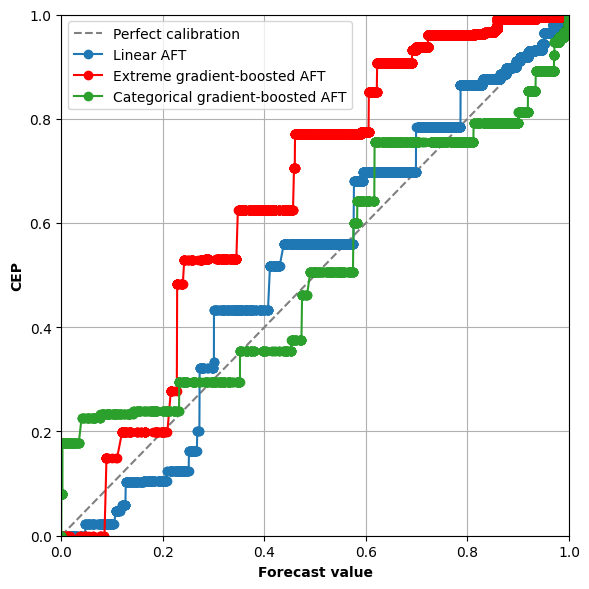

In [41]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Perfect calibration",
)


# model 1
corp_rel_diagram(
    y_true=array(observed_s_t_all[filter_nans_all]),
    y_prob=preds_s_t_ll[filter_nans_all],
    ax=ax,
    bands=None,
    plot_prob_hist=False,
    plot_cal_hist=False,
    score=False,
    label="Linear AFT",
    color="tab:blue",
)

# model 2
corp_rel_diagram(
    y_true=array(observed_s_t_all[filter_nans_all]),
    y_prob=preds_s_t_xgb[filter_nans_all],
    ax=ax,
    bands=None,
    plot_prob_hist=False,
    plot_cal_hist=False,
    score=False,
    label="Extreme gradient-boosted AFT",
)

# model 3
corp_rel_diagram(
    y_true=array(observed_s_t_all[filter_nans_all]),
    y_prob=preds_s_t_cb[filter_nans_all],
    ax=ax,
    bands=None,
    plot_prob_hist=False,
    plot_cal_hist=False,
    score=False,
    label="Categorical gradient-boosted AFT",
    color="tab:green",
)

ax.legend()
plt.tight_layout()
plt.show()

## Permanent

### Inladen data

In [20]:
permanent_teeth = pd.read_csv("../data/permanent_teeth.csv", sep=";")

### Preprocess data

In [21]:
permanent_teeth = preprocess_data_lifelines(permanent_teeth)

### inladen preds

In [22]:
# ll already has fixed order
permanent_preds_ll = pd.read_csv("./preds/ll_tooth_preds_perma.csv", sep=";")
permanent_preds_xgb = pd.read_csv("./preds/xgb_tooth_preds_perma.csv", sep=";")
permanent_preds_cb = pd.read_csv("./preds/cb_tooth_preds_perma.csv", sep=";")

In [23]:
# filter ll preds to have same order as deciduous_teeth
permanent_preds_ll["TOOTH_NUMBER"] = pd.Categorical(
    permanent_preds_ll["TOOTH_NUMBER"], permanent_teeth["TOOTH_NUMBER"].unique()
)
permanent_preds_ll = permanent_preds_ll.sort_values(
    ["DOG", "TOOTH_NUMBER", "DEVELOPM_STAGE"], ignore_index=True
)

In [24]:
# add dog, tooth_nr, developm_stage to xgb and cb
permanent_preds_xgb["DOG"] = permanent_teeth["DOG"]
permanent_preds_xgb["TOOTH_NUMBER"] = permanent_teeth["TOOTH_NUMBER"]
permanent_preds_xgb["DEVELOPM_STAGE"] = permanent_teeth["DEVELOPM_STAGE"]
permanent_preds_cb["DOG"] = permanent_teeth["DOG"]
permanent_preds_cb["TOOTH_NUMBER"] = permanent_teeth["TOOTH_NUMBER"]
permanent_preds_cb["DEVELOPM_STAGE"] = permanent_teeth["DEVELOPM_STAGE"]

### Brier Score

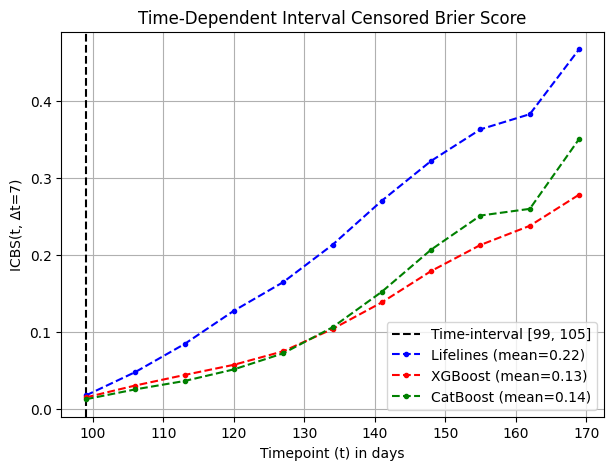

In [64]:
START_P = 99
END_P = 176
DELTA_P = 7

TIMEPOINTS_P = np.arange(START_P, END_P, DELTA_P)

# bs_lifelines_p = time_dependent_bs_lifelines(
#     permanent_preds_ll, TIMEPOINTS_P, DELTA_P, permanent_teeth
# )
# print(bs_lifelines_p)
bs_lifelines_p = [
    # np.float64(0.00020673888696690976),
    # np.float64(0.0028641446568891515),
    np.float64(0.018033914738364545),
    np.float64(0.048317453270087976),
    np.float64(0.08473543576227115),
    np.float64(0.127813639627487),
    np.float64(0.16493130514117),
    np.float64(0.2133659068361017),
    np.float64(0.2705100020985791),
    np.float64(0.32214623865022246),
    np.float64(0.36307525040187294),
    np.float64(0.38269691380880666),
    np.float64(0.46691939432590757),
    # np.float64(0.5574871266504704),
    # np.float64(0.7308672524367777),
    # np.float64(0.8905971876612183),
]

# bs_xgboost_p = time_dependent_bs_catboost(
#     permanent_preds_xgb, TIMEPOINTS_P, DELTA_P, permanent_teeth
# )
bs_xgboost_p = [
    # np.float64(0.002113416055552112),
    # np.float64(0.0051207560283679674),
    np.float64(0.015476162007459524),
    np.float64(0.030902887920899572),
    np.float64(0.04455285352087014),
    np.float64(0.057770281278325515),
    np.float64(0.07528674358860184),
    np.float64(0.10418719095080385),
    np.float64(0.13867091873637222),
    np.float64(0.17934704954841416),
    np.float64(0.2131571018333062),
    np.float64(0.23796856542581055),
    np.float64(0.2783609038372284),
    # np.float64(0.3274322955251506),
    # np.float64(0.3169670470777044),
    # np.float64(0.5030096192098825),
]

# bs_catboost_p = time_dependent_bs_catboost(
#     permanent_preds_cb, TIMEPOINTS_P, DELTA_P, permanent_teeth
# )
bs_catboost_p = [
    # np.float64(0.00017549351625713118),
    # np.float64(0.0025046963777640126),
    np.float64(0.013126860896239443),
    np.float64(0.025884884602344716),
    np.float64(0.03677930514375209),
    np.float64(0.0518064933566003),
    np.float64(0.07265715735268251),
    np.float64(0.1063976893643451),
    np.float64(0.1524880895128745),
    np.float64(0.2070995949050466),
    np.float64(0.2512834401848766),
    np.float64(0.2599551532219024),
    np.float64(0.35054763320413646),
    # np.float64(0.3724849895909505),
    # np.float64(0.5841434529709505),
    # np.float64(0.5749673342379423),
]

plt.figure(figsize=(7, 5))
# plt.axhline(y=0.25, color="gray", linestyle="--", label="Random predictor (ICBS=0.25)")
plt.axvline(x=99, color="black", linestyle="--", label="Time-interval [99, 105]")
plt.plot(
    TIMEPOINTS_P,
    bs_lifelines_p,
    marker=".",
    linestyle="--",
    color="blue",
    label=f"Lifelines (mean={np.mean(bs_lifelines_p):.2f})",
)
plt.plot(
    TIMEPOINTS_P,
    bs_xgboost_p,
    marker=".",
    linestyle="--",
    color="red",
    label=f"XGBoost (mean={np.mean(bs_xgboost_p):.2f})",
)
plt.plot(
    TIMEPOINTS_P,
    bs_catboost_p,
    marker=".",
    linestyle="--",
    color="green",
    label=f"CatBoost (mean={np.mean(bs_catboost_p):.2f})",
)
plt.xlabel("Timepoint (t) in days")
plt.ylabel(f"ICBS(t, Δt={DELTA_P})")
plt.title("Time-Dependent Interval Censored Brier Score")
plt.legend()
plt.grid()
plt.show()

[np.float64(0.00020673888696690976), np.float64(0.0028641446568891515), np.float64(0.018033914738364545), np.float64(0.048317453270087976), np.float64(0.08473543576227115), np.float64(0.127813639627487), np.float64(0.16493130514117), np.float64(0.2133659068361017), np.float64(0.2705100020985791), np.float64(0.32214623865022246), np.float64(0.36307525040187294), np.float64(0.38269691380880666), np.float64(0.46691939432590757), np.float64(0.5574871266504704), np.float64(0.7308672524367777), np.float64(0.8905971876612183)]


### AUC

In [25]:
kmf_p = get_kmf(permanent_teeth)

In [32]:
START_P = 99
END_P = 176
DELTA_P = 7

TIMEPOINTS_P = np.arange(START_P, END_P + 1, DELTA_P)

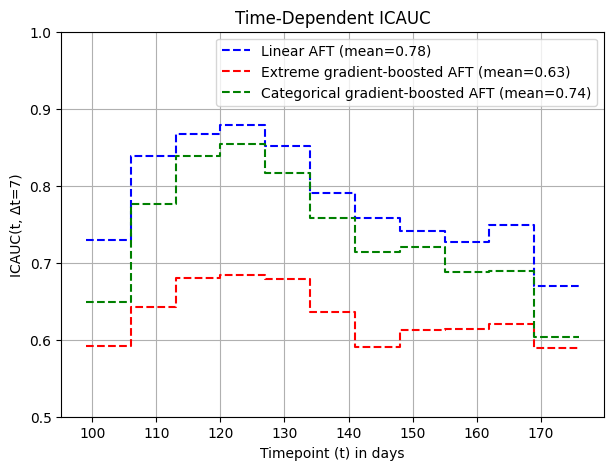

In [ ]:
aucs_lifelines_p = time_dependent_auc_lifelines(
    permanent_preds_ll, TIMEPOINTS_P, DELTA_P, permanent_teeth, kmf_p
)
print(aucs_lifelines_p)
# aucs_lifelines_p = [
#     np.float64(0.7299644945840623),
#     np.float64(0.83877237415648),
#     np.float64(0.8670702199867374),
#     np.float64(0.8784389925870623),
#     np.float64(0.8514900965246703),
#     np.float64(0.7903705711962492),
#     np.float64(0.7583106847611119),
#     np.float64(0.741664577640651),
#     np.float64(0.7271742756451595),
#     np.float64(0.7487830825115892),
#     np.float64(0.669717534088829),
#     np.float64(0.669717534088829),
#     # np.float64(0.6276105737952669),
# ]

aucs_xgboost_p = time_dependent_auc_catboost(
    permanent_preds_xgb, TIMEPOINTS_P, DELTA_P, permanent_teeth, kmf_p
)
print(aucs_xgboost_p)
# aucs_xgboost_p = [
#     np.float64(0.5913614905481885),
#     np.float64(0.6427157520712842),
#     np.float64(0.6807047772681079),
#     np.float64(0.684606359232392),
#     np.float64(0.6791872289013144),
#     np.float64(0.6362889487430035),
#     np.float64(0.5900779108934397),
#     np.float64(0.6121389036346337),
#     np.float64(0.6138597499163063),
#     np.float64(0.6199348318693534),
#     np.float64(0.5898701050056525),
#     np.float64(0.5898701050056525),
#     # np.float64(0.5168678859070096),
# ]

aucs_catboost_p = time_dependent_auc_catboost(
    permanent_preds_cb, TIMEPOINTS_P, DELTA_P, permanent_teeth, kmf_p
)
print(aucs_catboost_p)
# aucs_catboost_p = [
#     np.float64(0.6485782006877572),
#     np.float64(0.7765721831719998),
#     np.float64(0.8387174174735438),
#     np.float64(0.8541347103235909),
#     np.float64(0.8170377293005588),
#     np.float64(0.7584092375844602),
#     np.float64(0.7134714648465476),
#     np.float64(0.7207830771201593),
#     np.float64(0.6882434031059146),
#     np.float64(0.6887082916293373),
#     np.float64(0.6036741363925663),
#     np.float64(0.6036741363925663),
#     # np.float64(0.5369796607107704),
# ]

plt.figure(figsize=(7, 5))
plt.step(
    TIMEPOINTS_P,
    aucs_lifelines_p,
    where="post",
    color="blue",
    linestyle="--",
    label=f"Linear AFT (mean={np.mean(aucs_lifelines_p[:-1]):.2f})",
)

plt.step(
    TIMEPOINTS_P,
    aucs_xgboost_p,
    where="post",
    color="red",
    linestyle="--",
    label=f"Extreme gradient-boosted AFT (mean={np.mean(aucs_xgboost_p[:-1]):.2f})",
)

plt.step(
    TIMEPOINTS_P,
    aucs_catboost_p,
    where="post",
    linestyle="--",
    color="green",
    label=f"Categorical gradient-boosted AFT (mean={np.mean(aucs_catboost_p[:-1]):.2f})",
)

plt.ylim(0.5, 1)
plt.xlabel("Timepoint (t) in days")
plt.ylabel(f"ICAUC(t, Δt={DELTA_P})")
plt.title("Time-Dependent ICAUC")
plt.legend()
plt.grid()
plt.show()

### Calibration

In [42]:
observed_s_t_perma = binary_observered_eruption(permanent_teeth, 105)
filter_nans_perma = observed_s_t_perma[observed_s_t_perma.notna()].index.tolist()

preds_s_t_ll = (
    1 - permanent_preds_ll[permanent_preds_ll["time"] == 105]["pred_survival"].values
)

preds_s_t_xgb = []
for _, pat in permanent_preds_xgb.iterrows():
    preds_s_t_xgb.append(
        1 - compute_survival_probability(pat["pred"], 105, pat["dist"], pat["scale"])
    )
preds_s_t_xgb = array(preds_s_t_xgb)

preds_s_t_cb = []
for _, pat in permanent_preds_cb.iterrows():
    preds_s_t_cb.append(
        1 - compute_survival_probability(pat["pred"], 105, pat["dist"], pat["scale"])
    )
preds_s_t_cb = array(preds_s_t_cb)

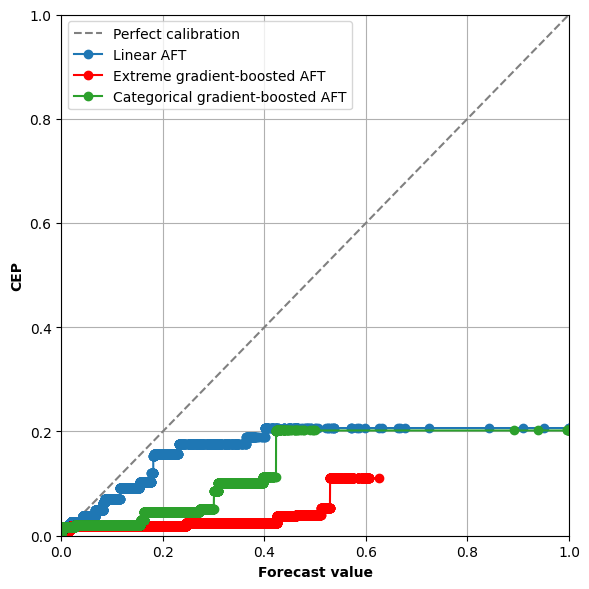

In [43]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Perfect calibration",
)


# model 1
corp_rel_diagram(
    y_true=array(observed_s_t_perma[filter_nans_perma]),
    y_prob=preds_s_t_ll[filter_nans_perma],
    ax=ax,
    bands=None,
    plot_prob_hist=False,
    plot_cal_hist=False,
    score=False,
    label="Linear AFT",
    color="tab:blue",
)

# model 2
corp_rel_diagram(
    y_true=array(observed_s_t_perma[filter_nans_perma]),
    y_prob=preds_s_t_xgb[filter_nans_perma],
    ax=ax,
    bands=None,
    plot_prob_hist=False,
    plot_cal_hist=False,
    score=False,
    label="Extreme gradient-boosted AFT",
)

# model 3
corp_rel_diagram(
    y_true=array(observed_s_t_perma[filter_nans_perma]),
    y_prob=preds_s_t_cb[filter_nans_perma],
    ax=ax,
    bands=None,
    plot_prob_hist=False,
    plot_cal_hist=False,
    score=False,
    label="Categorical gradient-boosted AFT",
    color="tab:green",
)

ax.legend()
plt.tight_layout()
plt.show()

## Comparison of per-tooth VS full data linear AFT

In [34]:
ll_preds_full = pd.read_csv(f"preds\\ll_dec_FULL_DATA.csv", sep=";")
ll_preds_perma_full = pd.read_csv(f"preds\\ll_perma_FULL_DATA.csv", sep=";")

In [35]:
# filter ll preds to have same order as deciduous_teeth
ll_preds_full["TOOTH_NUMBER"] = pd.Categorical(
    ll_preds_full["TOOTH_NUMBER"], deciduous_teeth_all["TOOTH_NUMBER"].unique()
)
ll_preds_full = ll_preds_full.sort_values(
    ["DOG", "TOOTH_NUMBER", "DEVELOPM_STAGE"], ignore_index=True
)

ll_preds_perma_full["TOOTH_NUMBER"] = pd.Categorical(
    ll_preds_perma_full["TOOTH_NUMBER"], permanent_teeth["TOOTH_NUMBER"].unique()
)
ll_preds_perma_full = ll_preds_perma_full.sort_values(
    ["DOG", "TOOTH_NUMBER", "DEVELOPM_STAGE"], ignore_index=True
)

In [36]:
aucs_lifelines = time_dependent_auc_lifelines(
    ll_preds, TIMEPOINTS, DELTA_D, deciduous_teeth_all, kmf_d
)
print(aucs_lifelines)
aucs_lifelines = time_dependent_auc_lifelines(
    ll_preds_full, TIMEPOINTS, DELTA_D, deciduous_teeth_all, kmf_d
)
print(aucs_lifelines)
aucs_lifelines = time_dependent_auc_lifelines(
    permanent_preds_ll, TIMEPOINTS_P, DELTA_P, permanent_teeth, kmf_p
)
print(aucs_lifelines)
aucs_lifelines = time_dependent_auc_lifelines(
    ll_preds_perma_full, TIMEPOINTS_P, DELTA_P, permanent_teeth, kmf_p
)
print(aucs_lifelines)

AUC at timepoint 11 is: 0.8932120839018683
AUC at timepoint 18 is: 0.9690418276343729
AUC at timepoint 25 is: 0.9400578540033779
AUC at timepoint 32 is: 0.8827489360209188
AUC at timepoint 39 is: 0.828494828971752
AUC at timepoint 46 is: 0.7194657688507049
AUC at timepoint 53 is: 0.6660684036603506
AUC at timepoint 60 is: 0.5461770359600943
[np.float64(0.8932120839018683), np.float64(0.9690418276343729), np.float64(0.9400578540033779), np.float64(0.8827489360209188), np.float64(0.828494828971752), np.float64(0.7194657688507049), np.float64(0.6660684036603506), np.float64(0.5461770359600943)]
AUC at timepoint 11 is: 0.8737624343900967
AUC at timepoint 18 is: 0.9040550756102352
AUC at timepoint 25 is: 0.8583943356592724
AUC at timepoint 32 is: 0.8080965871407708
AUC at timepoint 39 is: 0.7522950589994309
AUC at timepoint 46 is: 0.6587028749509629
AUC at timepoint 53 is: 0.5318667535457693
AUC at timepoint 60 is: 0.5946818418352378
[np.float64(0.8737624343900967), np.float64(0.90405507561

### Calibration

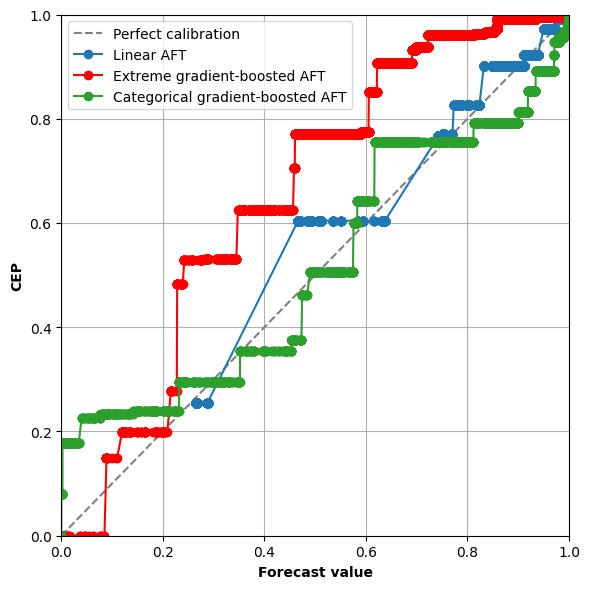

In [45]:
observed_s_t_all = binary_observered_eruption(deciduous_teeth_all, 56)
filter_nans_all = observed_s_t_all[observed_s_t_all.notna()].index.tolist()
preds_s_t_ll = 1 - ll_preds_full[ll_preds_full["time"] == 56]["pred_survival"].values

preds_s_t_xgb = []
for _, pat in xgb_preds.iterrows():
    preds_s_t_xgb.append(
        1 - compute_survival_probability(pat["pred"], 56, pat["dist"], pat["scale"])
    )
preds_s_t_xgb = array(preds_s_t_xgb)

preds_s_t_cb = []
for _, pat in cb_preds.iterrows():
    preds_s_t_cb.append(
        1 - compute_survival_probability(pat["pred"], 56, pat["dist"], pat["scale"])
    )
preds_s_t_cb = array(preds_s_t_cb)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Perfect calibration",
)


# model 1
corp_rel_diagram(
    y_true=array(observed_s_t_all[filter_nans_all]),
    y_prob=preds_s_t_ll[filter_nans_all],
    ax=ax,
    bands=None,
    plot_prob_hist=False,
    plot_cal_hist=False,
    score=False,
    label="Linear AFT",
    color="tab:blue",
)

# model 2
corp_rel_diagram(
    y_true=array(observed_s_t_all[filter_nans_all]),
    y_prob=preds_s_t_xgb[filter_nans_all],
    ax=ax,
    bands=None,
    plot_prob_hist=False,
    plot_cal_hist=False,
    score=False,
    label="Extreme gradient-boosted AFT",
)

# model 3
corp_rel_diagram(
    y_true=array(observed_s_t_all[filter_nans_all]),
    y_prob=preds_s_t_cb[filter_nans_all],
    ax=ax,
    bands=None,
    plot_prob_hist=False,
    plot_cal_hist=False,
    score=False,
    label="Categorical gradient-boosted AFT",
    color="tab:green",
)

ax.legend()
plt.tight_layout()
plt.show()

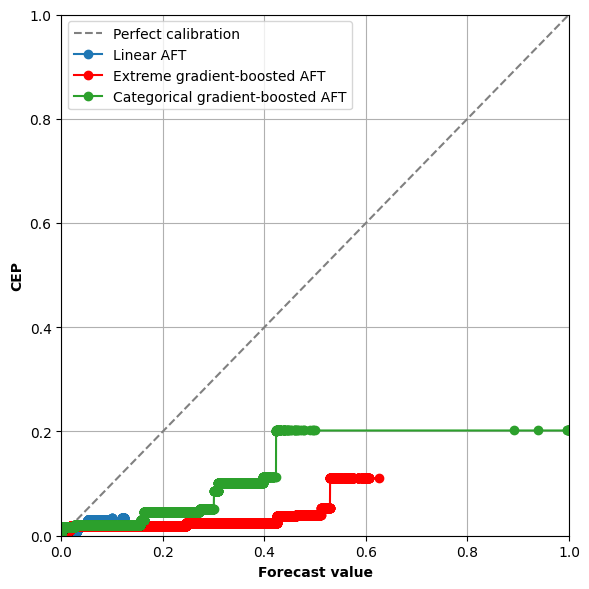

In [44]:
observed_s_t_perma = binary_observered_eruption(permanent_teeth, 105)
filter_nans_perma = observed_s_t_perma[observed_s_t_perma.notna()].index.tolist()

preds_s_t_ll = (
    1 - ll_preds_perma_full[ll_preds_perma_full["time"] == 105]["pred_survival"].values
)

preds_s_t_xgb = []
for _, pat in permanent_preds_xgb.iterrows():
    preds_s_t_xgb.append(
        1 - compute_survival_probability(pat["pred"], 105, pat["dist"], pat["scale"])
    )
preds_s_t_xgb = array(preds_s_t_xgb)

preds_s_t_cb = []
for _, pat in permanent_preds_cb.iterrows():
    preds_s_t_cb.append(
        1 - compute_survival_probability(pat["pred"], 105, pat["dist"], pat["scale"])
    )
preds_s_t_cb = array(preds_s_t_cb)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Perfect calibration",
)


# model 1
corp_rel_diagram(
    y_true=array(observed_s_t_perma[filter_nans_perma]),
    y_prob=preds_s_t_ll[filter_nans_perma],
    ax=ax,
    bands=None,
    plot_prob_hist=False,
    plot_cal_hist=False,
    score=False,
    label="Linear AFT",
    color="tab:blue",
)

# model 2
corp_rel_diagram(
    y_true=array(observed_s_t_perma[filter_nans_perma]),
    y_prob=preds_s_t_xgb[filter_nans_perma],
    ax=ax,
    bands=None,
    plot_prob_hist=False,
    plot_cal_hist=False,
    score=False,
    label="Extreme gradient-boosted AFT",
)

# model 3
corp_rel_diagram(
    y_true=array(observed_s_t_perma[filter_nans_perma]),
    y_prob=preds_s_t_cb[filter_nans_perma],
    ax=ax,
    bands=None,
    plot_prob_hist=False,
    plot_cal_hist=False,
    score=False,
    label="Categorical gradient-boosted AFT",
    color="tab:green",
)

ax.legend()
plt.tight_layout()
plt.show()